# Market regimes: detect, then adapt

Regime detection labels each day with the market state the detector believes it is in. This notebook shows the composite detector, what the regimes look like in the data, and the one test that matters: is the *timing* of the labels doing anything a placebo would not?

In [1]:
import logging, sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import load_config
from src.framework import Pipeline, load_default_bundle, load_library
logging.getLogger("src.backtest.engine").setLevel(logging.WARNING)
config = load_config(); load_library()
bundle = load_default_bundle(config)
print(f"{len(bundle.assets)} assets, {bundle.index[0].date()} to {bundle.index[-1].date()}")

15 assets, 2006-01-03 to 2026-09-21


In [2]:
from src.framework import DETECTORS
regimes = DETECTORS.create('composite').detect(bundle)
regimes.share().round(3)

LowVol       0.602
HighVol      0.144
Inflation    0.131
Deflation    0.105
Crisis       0.017
Name: proportion, dtype: float64

## The probabilities through time

The detector outputs a probability for each regime on each day, using only the information available that day (*filtered*, not *smoothed*).

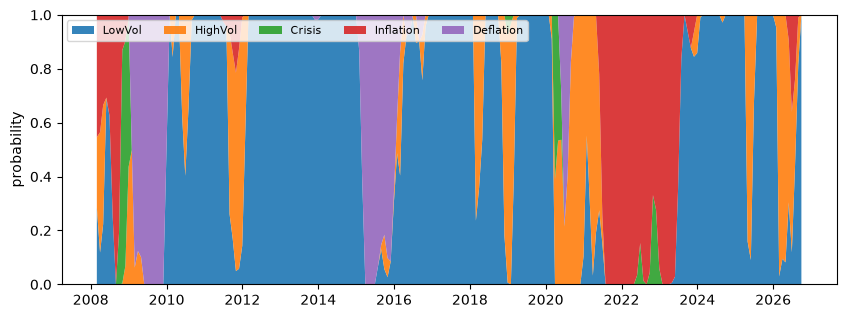

In [3]:
p = regimes.probabilities.dropna().resample('ME').mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.stackplot(p.index, [p[c] for c in p.columns], labels=list(p.columns), alpha=0.9)
ax.set_ylim(0, 1); ax.legend(ncol=5, fontsize=8, loc='upper left'); ax.set_ylabel('probability'); plt.show()

## Do regimes differ?

The annualised volatility and return of the equal-weight market proxy in each regime (hard labels). Volatility regimes are separated by construction, so large differences in volatility prove little; the test is whether *returns* differ.

In [4]:
proxy = bundle.returns.mean(axis=1)
labels = regimes.hard_labels().reindex(proxy.index)
table = proxy.groupby(labels).agg(days='size', ann_return=lambda x: x.mean() * 252, ann_vol=lambda x: x.std() * np.sqrt(252))
table.round(3)

,days,ann_return,ann_vol
Crisis,80,-0.293,0.443
Deflation,493,0.154,0.132
HighVol,677,0.122,0.134
Inflation,615,-0.031,0.109
LowVol,2823,0.086,0.075


## A placebo for regime timing

Take a simple timing rule: hold the equal-weight proxy, but go to cash the next day whenever the combined probability of HighVol and Crisis is above one half. Then shift the regime path by a random number of days and repeat. If the real path is not better than most shifted paths, the *timing* adds nothing.

In [5]:
risky = (regimes.probabilities[['HighVol', 'Crisis']].sum(axis=1).shift(1) > 0.5)
real = proxy.where(~risky, 0.0).dropna()
sharpe = lambda r: np.sqrt(252) * r.mean() / r.std()
rng = np.random.default_rng(7)
placebo = []
for _ in range(200):
    k = int(rng.integers(252, len(risky) - 252))
    shifted = pd.Series(np.roll(risky.to_numpy(), k), index=risky.index)
    placebo.append(sharpe(proxy.where(~shifted, 0.0).dropna()))
print(f'de-risk rule Sharpe {sharpe(real):.2f}; placebo mean {np.mean(placebo):.2f}; share of placebos at least as good {np.mean(np.array(placebo) >= sharpe(real)):.3f}')

de-risk rule Sharpe 0.69; placebo mean 0.68; share of placebos at least as good 0.395


Read the last number as a p-value. The platform's Stage 31 does this for the full adaptive allocator; see the technique guide on regime-adaptive allocation for what it found.